# CodeAlpha Disease Prediction

## Project Overview

This project develops a machine learning-based disease prediction system using patient health-related features.

The project includes data preprocessing, exploratory data analysis, multiple machine learning models, model comparison, performance evaluation, feature importance analysis, and real-world testing using user-provided patient symptoms/features.

## Objectives

- Preprocess and analyze the disease dataset.
- Train multiple machine learning classification models.
- Compare model performance and select the best model.
- Evaluate the selected model using appropriate metrics.
- Test the model using real-world patient inputs.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Download Dataset from Kaggle


In [3]:
# Download the Heart Disease Dataset from Kaggle
!pip -q install kagglehub
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("mexwell/heart-disease-dataset")
print("Dataset downloaded successfully!")
print("Path to dataset files:", path)
# Display files inside the downloaded folder
print("\nFiles available:")
for file in os.listdir(path):
    print("-", file)

100%|██████████| 399k/399k [00:00<00:00, 59.4MB/s]

Extracting files...
Dataset downloaded successfully!
Path to dataset files: /root/.cache/kagglehub/datasets/mexwell/heart-disease-dataset/versions/2

Files available:
- heart_statlog_cleveland_hungary_final.csv
- documentation.pdf


Load and Inspect the Dataset

In [4]:
import os
import pandas as pd
csv_path = os.path.join(path, "heart_statlog_cleveland_hungary_final.csv")
df = pd.read_csv(csv_path)
print("Dataset loaded successfully!")
print("=" * 60)
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
display(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset loaded successfully!
Dataset Shape: (1190, 12)

Column Names:
['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope', 'target']

First 5 Rows:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0



Data Types:
age                      int64
sex                      int64
chest pain type          int64
resting bp s             int64
cholesterol              int64
fasting blood sugar      int64
resting ecg              int64
max heart rate           int64
exercise angina          int64
oldpeak                float64
ST slope                 int64
target                   int64
dtype: object

Missing Values:
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Duplicate Rows: 272


Data Quality & Target Analysis

In [5]:
print("DATA QUALITY ANALYSIS")
print("=" * 60)
# Basic statistics
print("\n1. Dataset Shape")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
# Duplicate analysis
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100
print("\n2. Duplicate Analysis")
print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")
# Missing values
missing_total = df.isnull().sum().sum()
print("\n3. Missing Value Analysis")
print("Total missing values:", missing_total)
# Target distribution
print("\n4. Target Distribution")
print(df["target"].value_counts().sort_index())
print("\nTarget Percentage:")
print((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))
# Unique values for every feature
print("\n5. Unique Values")
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")
# Statistical summary
print("\n6. Statistical Summary")
display(df.describe().T)

DATA QUALITY ANALYSIS

1. Dataset Shape
Rows: 1190
Columns: 12

2. Duplicate Analysis
Duplicate rows: 272
Duplicate percentage: 22.86%

3. Missing Value Analysis
Total missing values: 0

4. Target Distribution
target
0    561
1    629
Name: count, dtype: int64

Target Percentage:
target
0    47.14
1    52.86
Name: proportion, dtype: float64

5. Unique Values
age: 50 unique values
sex: 2 unique values
chest pain type: 4 unique values
resting bp s: 67 unique values
cholesterol: 222 unique values
fasting blood sugar: 2 unique values
resting ecg: 3 unique values
max heart rate: 119 unique values
exercise angina: 2 unique values
oldpeak: 53 unique values
ST slope: 4 unique values
target: 2 unique values

6. Statistical Summary


,count,mean,std,min,25%,50%,75%,max
age,1190.0,53.720168,9.358203,28.0,47.0,54.0,60.00,77.0
sex,1190.0,0.763866,0.424884,0.0,1.0,1.0,1.00,1.0
chest pain type,1190.0,3.232773,0.935480,1.0,3.0,4.0,4.00,4.0
resting bp s,1190.0,132.153782,18.368823,0.0,120.0,130.0,140.00,200.0
cholesterol,1190.0,210.363866,101.420489,0.0,188.0,229.0,269.75,603.0
fasting blood sugar,1190.0,0.213445,0.409912,0.0,0.0,0.0,0.00,1.0
resting ecg,1190.0,0.698319,0.870359,0.0,0.0,0.0,2.00,2.0
max heart rate,1190.0,139.732773,25.517636,60.0,121.0,140.5,160.00,202.0
exercise angina,1190.0,0.387395,0.487360,0.0,0.0,0.0,1.00,1.0
oldpeak,1190.0,0.922773,1.086337,-2.6,0.0,0.6,1.60,6.2


Remove Duplicates & Create Clean Dataset

In [6]:
print("BEFORE CLEANING")
print("Rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
# Remove exact duplicate rows
df_clean = df.drop_duplicates().reset_index(drop=True)
print("\nAFTER CLEANING")
print("Rows:", len(df_clean))
print("Columns:", df_clean.shape[1])
print("Duplicate rows:", df_clean.duplicated().sum())
# Check target distribution after removing duplicates
print("\nTarget Distribution After Cleaning:")
display(df_clean["target"].value_counts().sort_index())
print("\nTarget Percentage After Cleaning:")
display(
    (df_clean["target"].value_counts(normalize=True).sort_index() * 100).round(2)
)

BEFORE CLEANING
Rows: 1190
Duplicate rows: 272

AFTER CLEANING
Rows: 918
Columns: 12
Duplicate rows: 0

Target Distribution After Cleaning:


,count
target,
0,410
1,508



Target Percentage After Cleaning:


,proportion
target,
0,44.66
1,55.34


Feature Groups

In [7]:
target_column = "target"
categorical_features = [
    "sex",
    "chest pain type",
    "fasting blood sugar",
    "resting ecg",
    "exercise angina",
    "ST slope"
]
numerical_features = [
    "age",
    "resting bp s",
    "cholesterol",
    "max heart rate",
    "oldpeak"
]
print("Categorical Features:")
print(categorical_features)
print("\nNumerical Features:")
print(numerical_features)
print("\nTotal Features:", len(categorical_features) + len(numerical_features))

Categorical Features:
['sex', 'chest pain type', 'fasting blood sugar', 'resting ecg', 'exercise angina', 'ST slope']

Numerical Features:
['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

Total Features: 11


Target & Feature Distribution

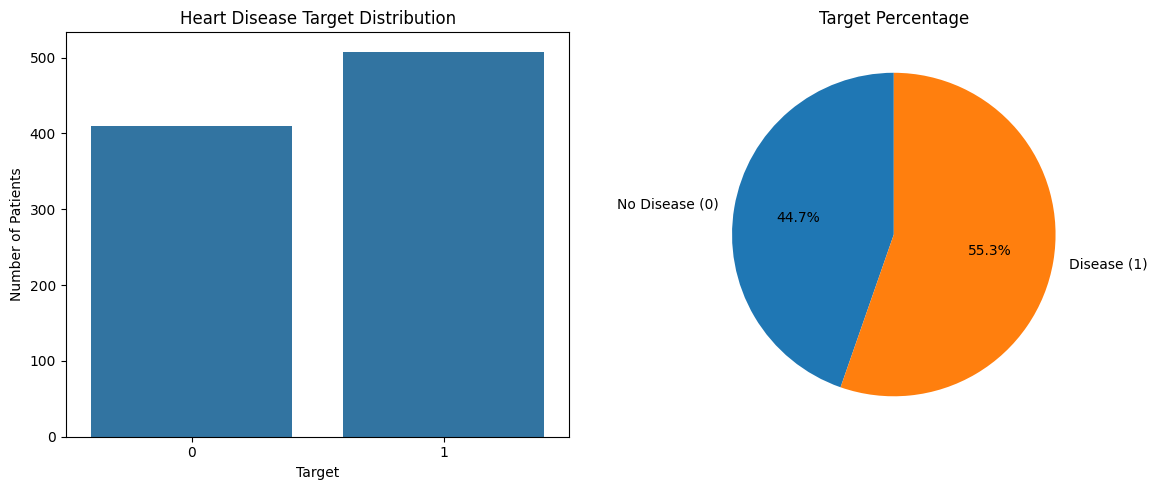

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df_clean, x="target", ax=axes[0])
axes[0].set_title("Heart Disease Target Distribution")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Number of Patients")
target_counts = df_clean["target"].value_counts().sort_index()
axes[1].pie(
    target_counts.values,
    labels=["No Disease (0)", "Disease (1)"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Target Percentage")
plt.tight_layout()
plt.show()

Detailed Feature Analysis

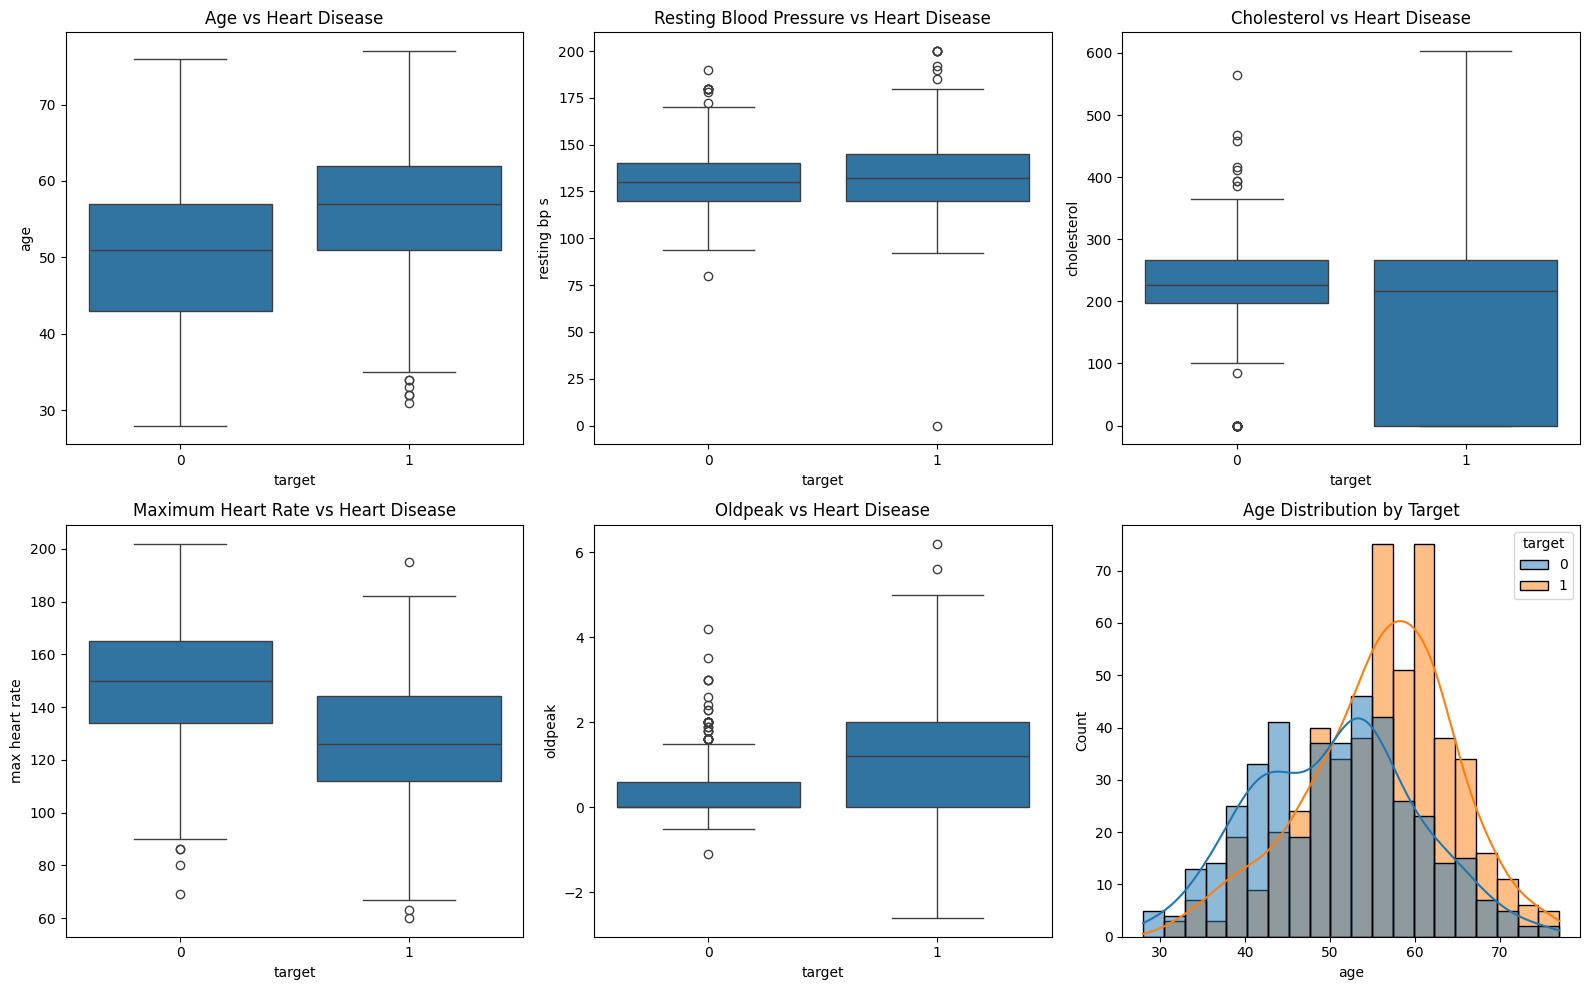

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# Age vs Target
sns.boxplot(data=df_clean, x="target", y="age", ax=axes[0, 0])
axes[0, 0].set_title("Age vs Heart Disease")
# Resting Blood Pressure
sns.boxplot(data=df_clean, x="target", y="resting bp s", ax=axes[0, 1])
axes[0, 1].set_title("Resting Blood Pressure vs Heart Disease")
# Cholesterol
sns.boxplot(data=df_clean, x="target", y="cholesterol", ax=axes[0, 2])
axes[0, 2].set_title("Cholesterol vs Heart Disease")
# Maximum Heart Rate
sns.boxplot(data=df_clean, x="target", y="max heart rate", ax=axes[1, 0])
axes[1, 0].set_title("Maximum Heart Rate vs Heart Disease")
# Oldpeak
sns.boxplot(data=df_clean, x="target", y="oldpeak", ax=axes[1, 1])
axes[1, 1].set_title("Oldpeak vs Heart Disease")
# Age distribution
sns.histplot(
    data=df_clean,
    x="age",
    hue="target",
    kde=True,
    bins=20,
    ax=axes[1, 2]
)
axes[1, 2].set_title("Age Distribution by Target")
plt.tight_layout()
plt.show()

Correlation Analysis

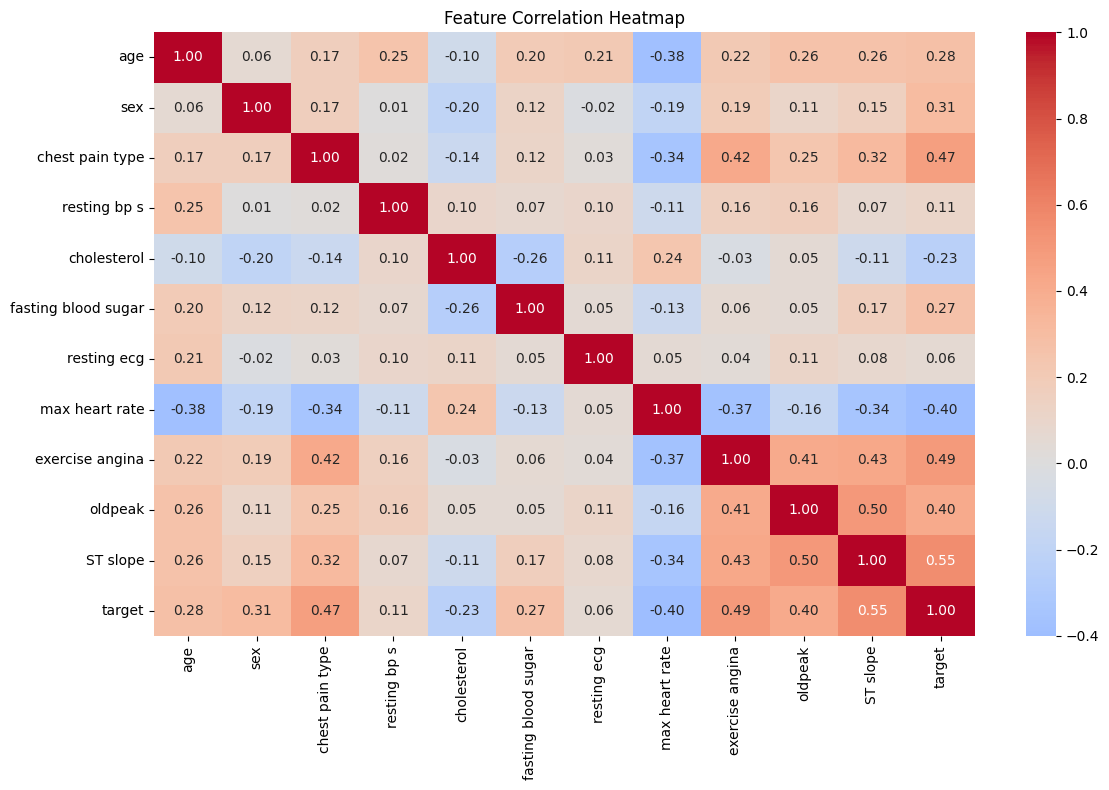

In [10]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Train/Test Split

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
X = df_clean.drop(columns=["target"])
y = df_clean["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training target distribution:")
print(y_train.value_counts().sort_index())

Training samples: 734
Testing samples: 184
Training target distribution:
target
0    328
1    406
Name: count, dtype: int64


Train 4 ML Models

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
trained_models = {}
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    print(f"✓ {name} trained successfully")

✓ Logistic Regression trained successfully
✓ Decision Tree trained successfully
✓ Random Forest trained successfully
✓ Gradient Boosting trained successfully


Model Comparison Chart

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
results = []
for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
model_results = pd.DataFrame(results)
model_results = model_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)
display(model_results.round(4))

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9022,0.8889,0.9412,0.9143,0.9392
1,Gradient Boosting,0.8913,0.9020,0.9020,0.9020,0.9319
2,Logistic Regression,0.8859,0.8716,0.9314,0.9005,0.9301
3,Decision Tree,0.8043,0.8235,0.8235,0.8235,0.8531


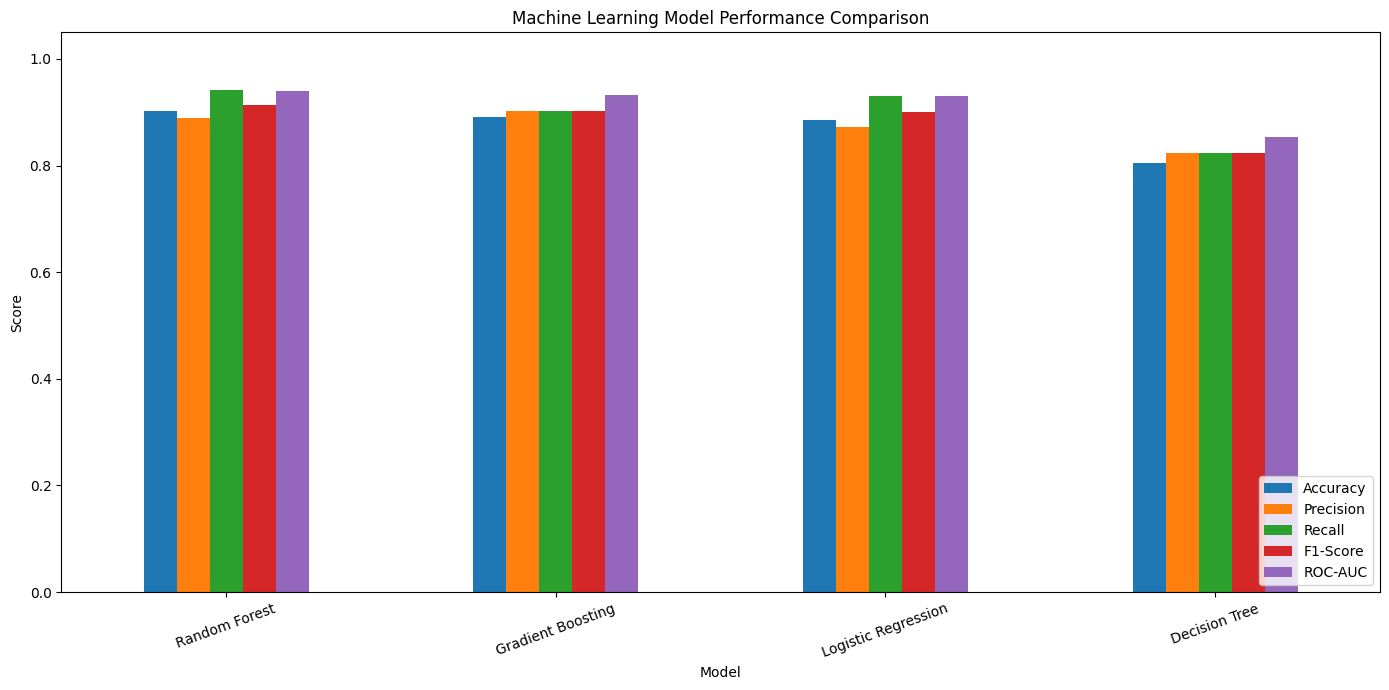

In [15]:
plot_data = model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]
ax = plot_data.plot(
    kind="bar",
    figsize=(14, 7)
)
plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Select Best Model

In [17]:
best_model_name = model_results.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("BEST MODEL SELECTION")
print("Selected Model:", best_model_name)
print("Selection Criterion: Highest ROC-AUC")
print("ROC-AUC Score:", round(model_results.iloc[0]["ROC-AUC"], 4))


BEST MODEL SELECTION
Selected Model: Random Forest
Selection Criterion: Highest ROC-AUC
ROC-AUC Score: 0.9392


Confusion Matrix and Classification Report

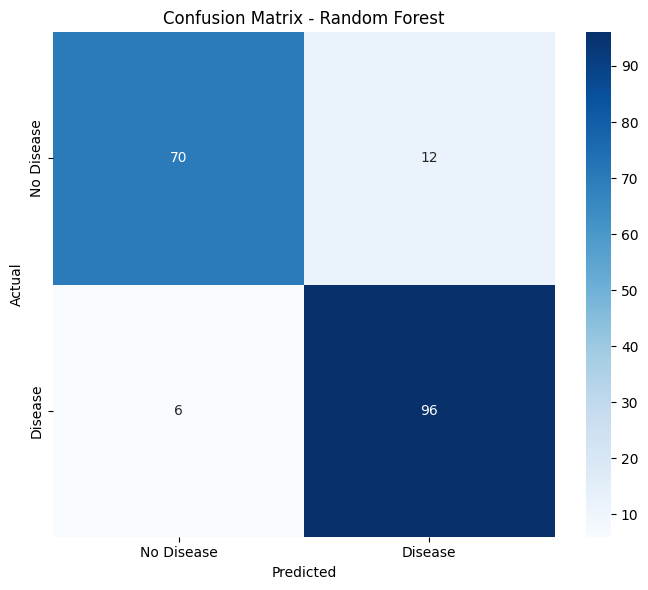

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.92      0.85      0.89        82
     Disease       0.89      0.94      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
# Predictions
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
# Classification Report
print("CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=["No Disease", "Disease"]
    )
)

ROC Curve and AUC

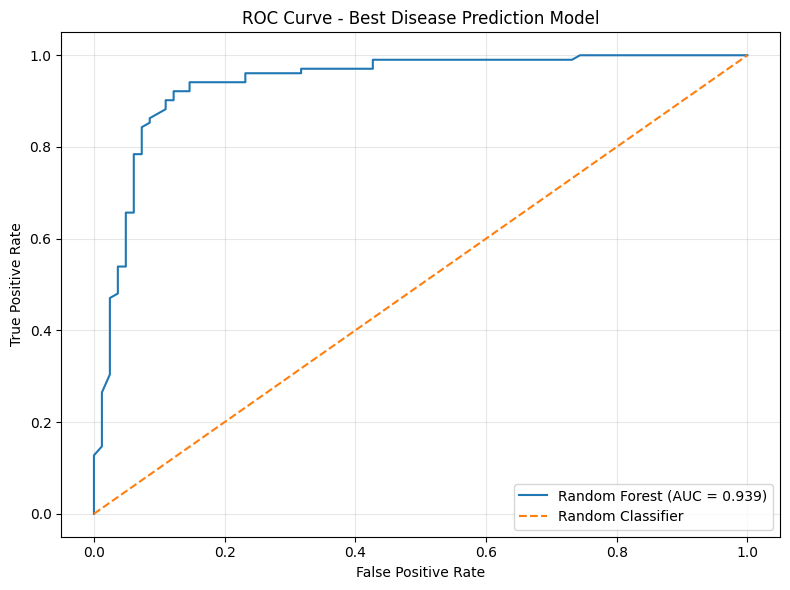

ROC-AUC ANALYSIS
Best Model: Random Forest
ROC-AUC Score: 0.9392


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"{best_model_name} (AUC = {auc_score:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)
plt.title("ROC Curve - Best Disease Prediction Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("ROC-AUC ANALYSIS")
print("Best Model:", best_model_name)
print("ROC-AUC Score:", round(auc_score, 4))

Feature Importance

TOP 15 FEATURE IMPORTANCE


,Feature,Importance
19,cat__ST slope_1,0.136326
20,cat__ST slope_2,0.108249
2,num__cholesterol,0.095530
3,num__max heart rate,0.094678
4,num__oldpeak,0.088105
10,cat__chest pain type_4,0.077375
0,num__age,0.070342
1,num__resting bp s,0.065070
17,cat__exercise angina_1,0.052354
16,cat__exercise angina_0,0.052274


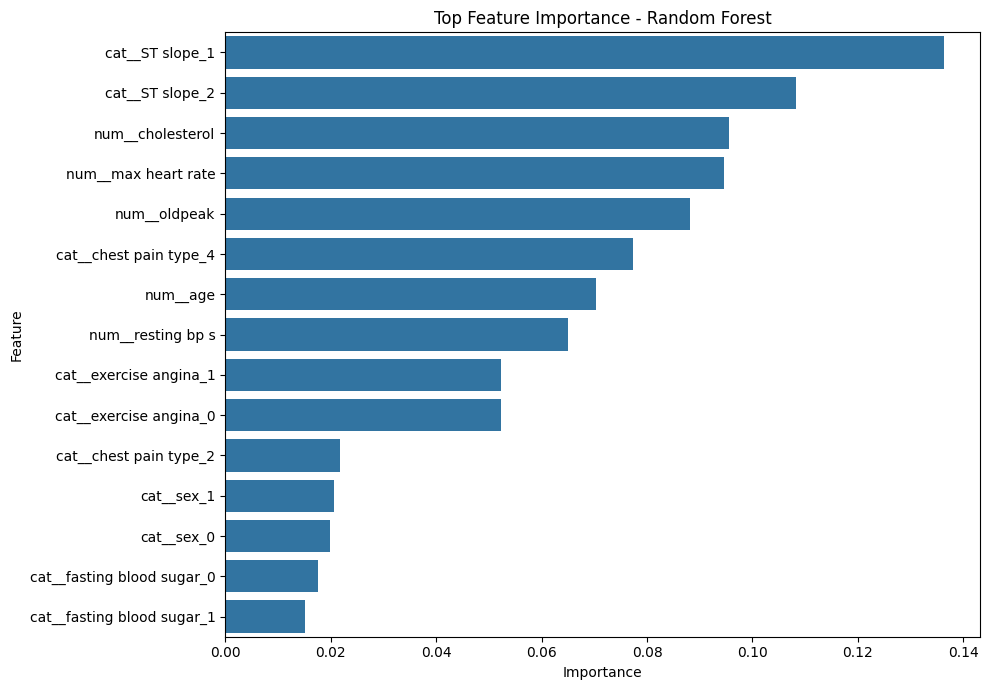

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Extract preprocessing and model objects
model_object = best_model.named_steps["model"]
preprocessing_object = best_model.named_steps["preprocessing"]
# Get transformed feature names
feature_names = preprocessing_object.get_feature_names_out()
# Get feature importance values
if hasattr(model_object, "feature_importances_"):
    importance_values = model_object.feature_importances_
else:
    importance_values = np.abs(model_object.coef_[0])
# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values(
    by="Importance",
    ascending=False
)
# Display top 15 features
top_features = feature_importance.head(15)
print("TOP 15 FEATURE IMPORTANCE")
display(top_features)
# Plot
plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)
plt.title(f"Top Feature Importance - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Real-World Patient Testing

UCI HEART DISEASE DATASET - EXTERNAL DATA INSPECTION

In [24]:
!pip -q install -U ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
print("DOWNLOADING UCI HEART DISEASE DATASET")
# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)
# Separate features and target
uci_X = heart_disease.data.features
uci_y = heart_disease.data.targets
print("\nDataset downloaded successfully!")
# ------------------------------------------------------------
# Dataset information
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("Dataset Name:", heart_disease.metadata.name)
print("UCI Dataset ID:", heart_disease.metadata.uci_id)
print("Number of Instances:", heart_disease.metadata.num_instances)
print("Number of Features:", heart_disease.metadata.num_features)
print("\nFeatures Shape:", uci_X.shape)
print("Target Shape:", uci_y.shape)
# ------------------------------------------------------------
# Column names
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FEATURE COLUMN NAMES")
print(uci_X.columns.tolist())
print("\nTarget Column:")
print(uci_y.columns.tolist())
# ------------------------------------------------------------
# First 5 rows
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FIRST 5 FEATURE ROWS")
display(uci_X.head())
print("\n" + "=" * 70)
print("FIRST 5 TARGET ROWS")
display(uci_y.head())
# ------------------------------------------------------------
# Data types
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("FEATURE DATA TYPES")
print(uci_X.dtypes)
# ------------------------------------------------------------
# Missing values
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("MISSING VALUES")
print(uci_X.isnull().sum())
print("\nTarget missing values:")
print(uci_y.isnull().sum())
# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("TARGET DISTRIBUTION")
print(uci_y.iloc[:, 0].value_counts(dropna=False).sort_index())
# ------------------------------------------------------------
# Dataset variables/documentation
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("UCI VARIABLE INFORMATION")
display(heart_disease.variables)

DOWNLOADING UCI HEART DISEASE DATASET

Dataset downloaded successfully!

DATASET INFORMATION
Dataset Name: Heart Disease
UCI Dataset ID: 45
Number of Instances: 303
Number of Features: 13

Features Shape: (303, 13)
Target Shape: (303, 1)

FEATURE COLUMN NAMES
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target Column:
['num']

FIRST 5 FEATURE ROWS


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



FIRST 5 TARGET ROWS


,num
0,0
1,2
2,1
3,0
4,0



FEATURE DATA TYPES
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

MISSING VALUES
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Target missing values:
num    0
dtype: int64

TARGET DISTRIBUTION
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

UCI VARIABLE INFORMATION


,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,None,years,no
1,sex,Feature,Categorical,Sex,None,None,no
2,cp,Feature,Categorical,None,None,None,no
3,trestbps,Feature,Integer,None,resting blood pressure (on admission to the ho...,mm Hg,no
4,chol,Feature,Integer,None,serum cholestoral,mg/dl,no
5,fbs,Feature,Categorical,None,fasting blood sugar > 120 mg/dl,None,no
6,restecg,Feature,Categorical,None,None,None,no
7,thalach,Feature,Integer,None,maximum heart rate achieved,None,no
8,exang,Feature,Categorical,None,exercise induced angina,None,no
9,oldpeak,Feature,Integer,None,ST depression induced by exercise relative to ...,None,no


Prepare UCI External Validation Data

In [25]:
print("=" * 70)
print("PREPARING UCI DATA FOR EXTERNAL VALIDATION")
print("=" * 70)
# Copy UCI data
external_df = uci_X.copy()
external_target = uci_y["num"].copy()
# Convert UCI target:
# 0 = No Disease
# 1,2,3,4 = Disease
external_target_binary = (external_target > 0).astype(int)
# ------------------------------------------------------------
# Map UCI feature names to the feature names used by our model
# ------------------------------------------------------------
external_df = external_df.rename(columns={
    "cp": "chest pain type",
    "trestbps": "resting bp s",
    "chol": "cholesterol",
    "fbs": "fasting blood sugar",
    "restecg": "resting ecg",
    "thalach": "max heart rate",
    "exang": "exercise angina",
    "slope": "ST slope"
})
# ------------------------------------------------------------
# Select only features available in our trained model
# ------------------------------------------------------------
required_features = [
    "age",
    "sex",
    "chest pain type",
    "resting bp s",
    "cholesterol",
    "fasting blood sugar",
    "resting ecg",
    "max heart rate",
    "exercise angina",
    "oldpeak",
    "ST slope"
]
external_X = external_df[required_features].copy()
# ------------------------------------------------------------
# Handle missing values
# ------------------------------------------------------------
print("\nMissing values before processing:")
print(external_X.isnull().sum())
# Remove rows with missing values in the selected features
valid_rows = external_X.notnull().all(axis=1)
external_X = external_X.loc[valid_rows].reset_index(drop=True)
external_y = external_target_binary.loc[valid_rows].reset_index(drop=True)
print("\nRows available for external validation:", len(external_X))
print("\nExternal feature shape:", external_X.shape)
print("\nExternal target distribution:")
print(
    external_y.value_counts()
    .sort_index()
    .rename(index={0: "No Disease", 1: "Disease"})
)
print("\n" + "=" * 70)
print("EXTERNAL VALIDATION DATA READY")
display(external_X.head())

PREPARING UCI DATA FOR EXTERNAL VALIDATION

Missing values before processing:
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
dtype: int64

Rows available for external validation: 303

External feature shape: (303, 11)

External target distribution:
num
No Disease    164
Disease       139
Name: count, dtype: int64

EXTERNAL VALIDATION DATA READY


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope
0,63,1,1,145,233,1,2,150,0,2.3,3
1,67,1,4,160,286,0,2,108,1,1.5,2
2,67,1,4,120,229,0,2,129,1,2.6,2
3,37,1,3,130,250,0,0,187,0,3.5,3
4,41,0,2,130,204,0,2,172,0,1.4,1


Perform External Validation

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
print("EXTERNAL VALIDATION RESULTS")
# Generate predictions using the already-trained model
external_predictions = best_model.predict(external_X)
external_probabilities = best_model.predict_proba(external_X)[:, 1]
# ------------------------------------------------------------
# Calculate performance metrics
# ------------------------------------------------------------
external_accuracy = accuracy_score(
    external_y,
    external_predictions
)

external_precision = precision_score(
    external_y,
    external_predictions,
    zero_division=0
)
external_recall = recall_score(
    external_y,
    external_predictions,
    zero_division=0
)
external_f1 = f1_score(
    external_y,
    external_predictions,
    zero_division=0
)
external_auc = roc_auc_score(
    external_y,
    external_probabilities
)
# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
print("\nAccuracy :", round(external_accuracy, 4))
print("Precision:", round(external_precision, 4))
print("Recall   :", round(external_recall, 4))
print("F1-Score :", round(external_f1, 4))
print("ROC-AUC  :", round(external_auc, 4))
# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------
external_cm = confusion_matrix(
    external_y,
    external_predictions
)
print("\n" + "=" * 70)
print("EXTERNAL CONFUSION MATRIX")
print(external_cm)
# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("EXTERNAL CLASSIFICATION REPORT")
print(
    classification_report(
        external_y,
        external_predictions,
        target_names=["No Disease", "Disease"]
    )
)

EXTERNAL VALIDATION RESULTS

Accuracy : 0.9736
Precision: 0.9712
Recall   : 0.9712
F1-Score : 0.9712
ROC-AUC  : 0.9862

EXTERNAL CONFUSION MATRIX
[[160   4]
 [  4 135]]

EXTERNAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.98      0.98      0.98       164
     Disease       0.97      0.97      0.97       139

    accuracy                           0.97       303
   macro avg       0.97      0.97      0.97       303
weighted avg       0.97      0.97      0.97       303



External Validation Confusion Matrix

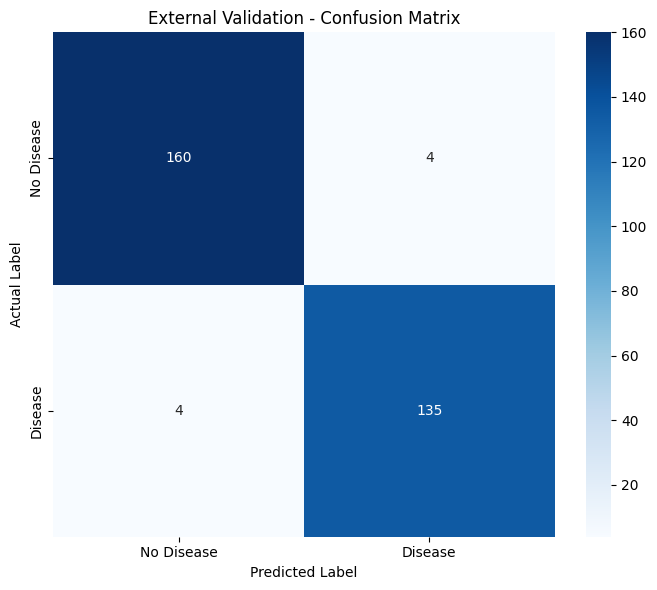

In [28]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    external_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)
plt.title("External Validation - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

External ROC Curve

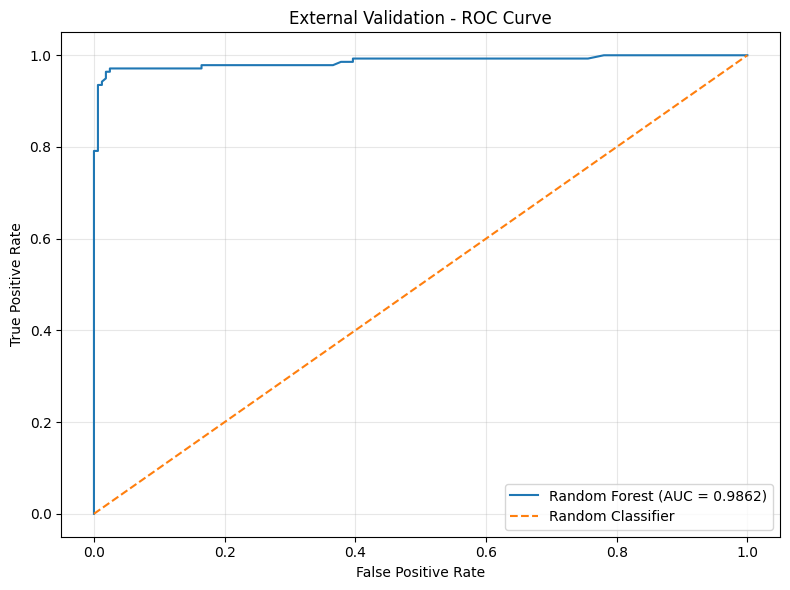

EXTERNAL ROC-AUC
Model: Random Forest
External ROC-AUC: 0.9862


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Calculate ROC values
external_fpr, external_tpr, external_thresholds = roc_curve(
    external_y,
    external_probabilities
)
external_auc = roc_auc_score(
    external_y,
    external_probabilities
)
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(
    external_fpr,
    external_tpr,
    label=f"Random Forest (AUC = {external_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)
plt.title("External Validation - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("EXTERNAL ROC-AUC")
print("Model:", best_model_name)
print("External ROC-AUC:", round(external_auc, 4))

Save Complete External Validation Results

In [31]:
import os
import pandas as pd
# Create results directory
os.makedirs("results", exist_ok=True)
# Create validation results DataFrame
external_results = external_X.copy()
external_results["Actual"] = external_y.values
external_results["Predicted"] = external_predictions
external_results["Disease_Probability"] = external_probabilities
external_results["No_Disease_Probability"] = 1 - external_probabilities
# Convert numerical classes to readable labels
external_results["Actual_Label"] = external_results["Actual"].map({
    0: "No Disease",
    1: "Disease"
})
external_results["Predicted_Label"] = external_results["Predicted"].map({
    0: "No Disease",
    1: "Disease"
})
# Prediction correctness
external_results["Correct_Prediction"] = (
    external_results["Actual"] == external_results["Predicted"]
)
# Risk category based on model probability
external_results["Risk_Category"] = pd.cut(
    external_results["Disease_Probability"],
    bins=[-0.01, 0.30, 0.70, 1.00],
    labels=["Low", "Moderate", "High"]
)
# Save CSV
external_results_path = "results/external_validation_results.csv"
external_results.to_csv(
    external_results_path,
    index=False
)
print("=" * 70)
print("EXTERNAL VALIDATION RESULTS SAVED")
print("=" * 70)
print("File:", external_results_path)
print("Total External Cases:", len(external_results))
print("Correct Predictions:", external_results["Correct_Prediction"].sum())
print(
    "Incorrect Predictions:",
    (~external_results["Correct_Prediction"]).sum()
)
print(
    "External Accuracy:",
    f"{external_results['Correct_Prediction'].mean() * 100:.2f}%"
)
print("\nFirst 10 External Validation Results:")
display(external_results.head(10))

EXTERNAL VALIDATION RESULTS SAVED
File: results/external_validation_results.csv
Total External Cases: 303
Correct Predictions: 295
Incorrect Predictions: 8
External Accuracy: 97.36%

First 10 External Validation Results:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,Actual,Predicted,Disease_Probability,No_Disease_Probability,Actual_Label,Predicted_Label,Correct_Prediction,Risk_Category
0,63,1,1,145,233,1,2,150,0,2.3,3,0,0,0.243333,0.756667,No Disease,No Disease,True,Low
1,67,1,4,160,286,0,2,108,1,1.5,2,1,1,0.990000,0.010000,Disease,Disease,True,High
2,67,1,4,120,229,0,2,129,1,2.6,2,1,1,0.983333,0.016667,Disease,Disease,True,High
3,37,1,3,130,250,0,0,187,0,3.5,3,0,0,0.166667,0.833333,No Disease,No Disease,True,Low
4,41,0,2,130,204,0,2,172,0,1.4,1,0,0,0.023333,0.976667,No Disease,No Disease,True,Low
5,56,1,2,120,236,0,0,178,0,0.8,1,0,0,0.046667,0.953333,No Disease,No Disease,True,Low
6,62,0,4,140,268,0,2,160,0,3.6,3,1,1,0.806667,0.193333,Disease,Disease,True,High
7,57,0,4,120,354,0,0,163,1,0.6,1,0,0,0.196667,0.803333,No Disease,No Disease,True,Low
8,63,1,4,130,254,0,2,147,0,1.4,2,1,1,0.893333,0.106667,Disease,Disease,True,High
9,53,1,4,140,203,1,2,155,1,3.1,3,1,1,0.940000,0.060000,Disease,Disease,True,High


Save External ROC Curve

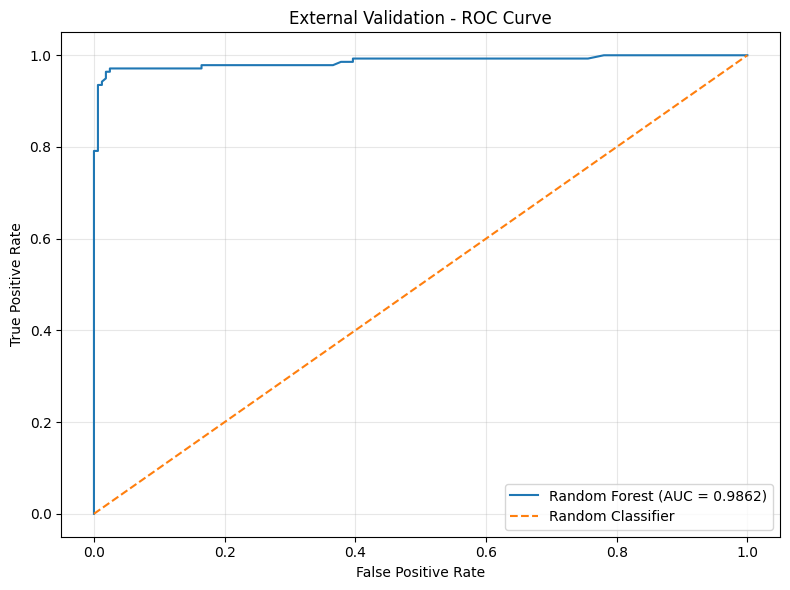

EXTERNAL ROC CURVE SAVED
File: results/external_roc_curve.png
ROC-AUC: 0.9862


In [32]:
import os
import matplotlib.pyplot as plt
os.makedirs("results", exist_ok=True)
plt.figure(figsize=(8, 6))
plt.plot(
    external_fpr,
    external_tpr,
    label=f"{best_model_name} (AUC = {external_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random Classifier"
)
plt.title("External Validation - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
external_roc_path = "results/external_roc_curve.png"
plt.savefig(
    external_roc_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("EXTERNAL ROC CURVE SAVED")
print("File:", external_roc_path)
print("ROC-AUC:", round(external_auc, 4))

In [33]:
# Checking whether external UCI records overlap with the training dataset
train_feature_set = set(
    map(tuple, df_clean[required_features].astype(str).values)
)
external_feature_set = set(
    map(tuple, external_X.astype(str).values)
)
overlap_count = len(train_feature_set.intersection(external_feature_set))
print("Training dataset unique feature rows:", len(train_feature_set))
print("External UCI unique feature rows:", len(external_feature_set))
print("Exact feature-row overlap:", overlap_count)

if overlap_count == 0:
    print(" No exact overlap detected.")
else:
    print(" Exact overlap detected.")

Training dataset unique feature rows: 918
External UCI unique feature rows: 303
Exact feature-row overlap: 303
 Exact overlap detected.


In [34]:
overlap_summary = pd.DataFrame({
    "Metric": [
        "Training dataset unique rows",
        "UCI evaluation rows",
        "Exact overlapping rows",
        "External accuracy",
        "External precision",
        "External recall",
        "External F1",
        "External ROC-AUC"
    ],
    "Value": [
        len(train_feature_set),
        len(external_feature_set),
        overlap_count,
        external_accuracy,
        external_precision,
        external_recall,
        external_f1,
        external_auc
    ]
})
overlap_summary.to_csv(
    "results/validation_summary.csv",
    index=False
)
print("Validation summary saved successfully.")
print(overlap_summary)

Validation summary saved successfully.
                         Metric       Value
0  Training dataset unique rows  918.000000
1           UCI evaluation rows  303.000000
2        Exact overlapping rows  303.000000
3             External accuracy    0.973597
4            External precision    0.971223
5               External recall    0.971223
6                   External F1    0.971223
7              External ROC-AUC    0.986248


Results Summary

In [36]:
best_test_predictions = best_model.predict(X_test)
best_test_probabilities = best_model.predict_proba(X_test)[:, 1]
best_test_accuracy = accuracy_score(y_test, best_test_predictions)
best_test_precision = precision_score(y_test, best_test_predictions, zero_division=0)
best_test_recall = recall_score(y_test, best_test_predictions, zero_division=0)
best_test_f1 = f1_score(y_test, best_test_predictions, zero_division=0)
best_test_auc = roc_auc_score(y_test, best_test_probabilities)
final_results = pd.DataFrame({
    "Evaluation": [
        "Held-out Test Set",
        "UCI Cross-Source Check"
    ],
    "Model": [
        best_model_name,
        best_model_name
    ],
    "Accuracy": [
        best_test_accuracy,
        external_accuracy
    ],
    "Precision": [
        best_test_precision,
        external_precision
    ],
    "Recall": [
        best_test_recall,
        external_recall
    ],
    "F1_Score": [
        best_test_f1,
        external_f1
    ],
    "ROC_AUC": [
        best_test_auc,
        external_auc
    ]
})
final_results.to_csv("results/final_model_results.csv", index=False)
print("Final model results saved successfully!")
print(final_results.round(4))

Final model results saved successfully!
               Evaluation          Model  Accuracy  Precision  Recall  \
0       Held-out Test Set  Random Forest    0.9022     0.8889  0.9412   
1  UCI Cross-Source Check  Random Forest    0.9736     0.9712  0.9712   

   F1_Score  ROC_AUC  
0    0.9143   0.9392  
1    0.9712   0.9862  


Results Folder

In [37]:
import os
print("===== FINAL RESULTS FILES =====")
for file in sorted(os.listdir("results")):
    file_path = os.path.join("results", file)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"{file:<40} {size_kb:.1f} KB")

===== FINAL RESULTS FILES =====
external_roc_curve.png                   133.6 KB
external_validation_results.csv          28.7 KB
final_model_results.csv                  0.3 KB
validation_summary.csv                   0.3 KB
